<a href="https://colab.research.google.com/github/patty-gz02/Colaboratory/blob/main/TasasInteres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h2>Modelo predictivo para la demanda de negocios en la región Moquegua para preveer el cierre prematuro</h2>**







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model as sklm
import seaborn as sns
from sklearn.linear_model import LinearRegression
%matplotlib inline



```
from google.colab import files
uploaded=files.upload()
# Verificar el nombre del archivo cargado
archivo_xlsx = list(uploaded.keys())[0]

# Leer el archivo xlsx con pandas
datos_xlsx = pd.read_excel(archivo_xlsx)

# Especificar la ruta para guardar el archivo CSV
archivo_csv = '/content/sample_data/resume2.csv'

# Guardar los datos en un archivo CSV
datos_xlsx.to_csv(archivo_csv, index=False)

print(f'La conversión de {archivo_xlsx} a {archivo_csv} se ha completado.')
```



In [ ]:
from google.colab import files
uploaded=files.upload()

Saving directorio.csv to directorio.csv
Saving resume2.csv to resume2.csv


In [ ]:
dataset=pd.read_csv("directorio.csv")
print(dataset.head())

  fecha_inicio  fecha_alta  fecha_baja  duracion tipo_empresa  estado  \
0   2018-03-14  2018-03-14  2023-12-20       5.0            7     0.0   
1   2019-03-08  2019-03-08  2023-12-20       4.0           39     0.0   
2   2019-08-15  2019-08-15  2023-12-20       4.0            2     0.0   
3   2019-11-14  2019-11-14  2019-12-01       0.0            2    10.0   
4   2023-05-08  2023-05-04  2023-12-20       0.0            2     0.0   

   distrito       provincia                             descrip ciiu  
0  MOQUEGUA  MARISCAL NIETO      TRANSPORTE  DE CARGA POR CARRETERA.  
1  MOQUEGUA  MARISCAL NIETO          VENTA DE VEHICULOS AUTOMOTORES.  
2  MOQUEGUA  MARISCAL NIETO          OTROS TIPOS DE VENTA POR MENOR.  
3  MOQUEGUA  MARISCAL NIETO  VTA.  MAY. A CAMBIO DE UNA RETRIBUCION.  
4  MOQUEGUA  MARISCAL NIETO          RESTAURANTES, BARES Y CANTINAS.  


In [ ]:
resumen=pd.read_csv("resume2.csv")
print(resumen.head())

   Código CIIU             Sector e Industria Tipo de Sector  \
0         4782  Comercio - Venta al por menor      Terciario   
1         4759  Comercio - Venta al por menor      Terciario   
2         4781  Comercio - Venta al por menor      Terciario   
3         4773  Comercio - Venta al por menor      Terciario   
4         4791  Comercio - Venta al por menor      Terciario   

                          Nombre del CIIU Tipo_Demanda MercadoObjetivo  \
0  VTA. MIN. PRODUCTOS TEXTILES, CALZADO.        Medio           Medio   
1       VTA. MIN. EQUIPO DE USO DOMESTICO   Medio-alto            Alto   
2           VTA. MIN. EN PUESTOS DE VENTA        Medio           Medio   
3   VTA. MIN. EN ALMACENES NO ESPECIALIZ.        Medio            Alto   
4  VTA. MIN. DE CASAS DE VENTA POR CORREO        Medio           Medio   

   Costo_min  Costo_max  
0       2000       8000  
1       3000      10000  
2       1500       6000  
3       4000      12000  
4       2500       8000  


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12651 entries, 0 to 12650
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha_inicio  12647 non-null  object 
 1   fecha_alta    12647 non-null  object 
 2   fecha_baja    12647 non-null  object 
 3   duracion      12648 non-null  float64
 4   tipo_empresa  12647 non-null  object 
 5   estado        12647 non-null  float64
 6   distrito      12647 non-null  object 
 7   provincia     12647 non-null  object 
 8   descrip ciiu  9514 non-null   object 
dtypes: float64(2), object(7)
memory usage: 889.6+ KB


In [ ]:
resumen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Código CIIU         142 non-null    int64 
 1   Sector e Industria  142 non-null    object
 2   Tipo de Sector      142 non-null    object
 3   Nombre del CIIU     142 non-null    object
 4   Tipo_Demanda        142 non-null    object
 5   MercadoObjetivo     142 non-null    object
 6   Costo_min           142 non-null    int64 
 7   Costo_max           142 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 9.0+ KB


In [ ]:
dataset.isnull().tail() # obtenemos una matrix boleana donde se muestra datos nulos

,fecha_inicio,fecha_alta,fecha_baja,duracion,tipo_empresa,estado,distrito,provincia,descrip ciiu
12646,False,False,False,False,False,False,False,False,False
12647,False,False,False,False,False,False,False,False,False
12648,False,False,False,False,False,False,False,False,False
12649,False,False,False,False,False,False,False,False,True
12650,False,False,False,False,False,False,False,False,True


**heatmap()** de la biblioteca Seaborn, la cual crea un mapa de calor, una representación visual que utiliza colores para mostrar la distribución de valores en una matriz.

<Axes: >

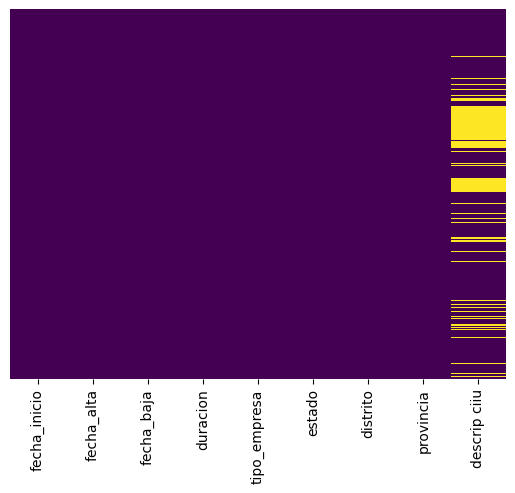

In [ ]:
sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
print(dataset.isnull().sum().sum())

3168


In [ ]:
dataset.dropna(inplace=True)

<Axes: >

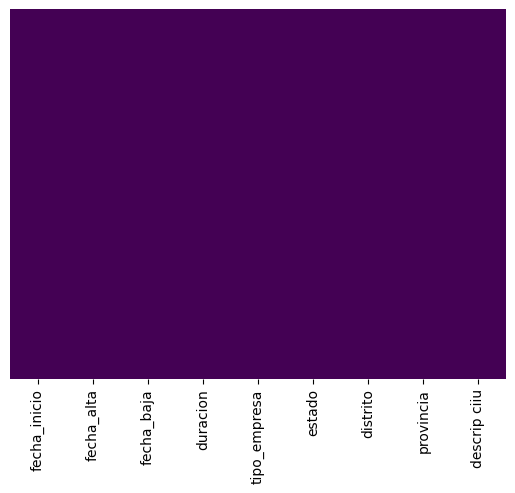

In [ ]:
sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
print(dataset.isnull().sum().sum())

0


In [ ]:
dataset.shape

(9514, 9)

In [ ]:
resumen.shape

(142, 8)

In [ ]:
dataset.head()

,fecha_inicio,fecha_alta,fecha_baja,duracion,tipo_empresa,estado,distrito,provincia,descrip ciiu
0,2018-03-14,2018-03-14,2023-12-20,5.0,7,0.0,MOQUEGUA,MARISCAL NIETO,TRANSPORTE DE CARGA POR CARRETERA.
1,2019-03-08,2019-03-08,2023-12-20,4.0,39,0.0,MOQUEGUA,MARISCAL NIETO,VENTA DE VEHICULOS AUTOMOTORES.
2,2019-08-15,2019-08-15,2023-12-20,4.0,2,0.0,MOQUEGUA,MARISCAL NIETO,OTROS TIPOS DE VENTA POR MENOR.
3,2019-11-14,2019-11-14,2019-12-01,0.0,2,10.0,MOQUEGUA,MARISCAL NIETO,VTA. MAY. A CAMBIO DE UNA RETRIBUCION.
4,2023-05-08,2023-05-04,2023-12-20,0.0,2,0.0,MOQUEGUA,MARISCAL NIETO,"RESTAURANTES, BARES Y CANTINAS."


**factorize()** para convertir la columna en una variable categórica, asignando a cada categoría un número entero.

In [ ]:
#Cambiar el distrito tipo texto a numerico
dataset['distrito'] = pd.factorize(dataset.iloc[:,6])[0]

In [ ]:
#Cambiar el provincia tipo texto a numerico
dataset['provincia'] = pd.factorize(dataset.iloc[:,7])[0]

In [ ]:
#Cambiar el ciiu tipo texto a numerico
dataset['ciiu'] = pd.factorize(dataset.iloc[:,8])[0]

In [ ]:
dataset.head()

In [ ]:
resumen.head()

,Código CIIU,Sector e Industria,Tipo de Sector,Nombre del CIIU,Tipo_Demanda,MercadoObjetivo,Costo_min,Costo_max
0,4782,Comercio - Venta al por menor,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000
1,4759,Comercio - Venta al por menor,Terciario,VTA. MIN. EQUIPO DE USO DOMESTICO,Medio-alto,Alto,3000,10000
2,4781,Comercio - Venta al por menor,Terciario,VTA. MIN. EN PUESTOS DE VENTA,Medio,Medio,1500,6000
3,4773,Comercio - Venta al por menor,Terciario,VTA. MIN. EN ALMACENES NO ESPECIALIZ.,Medio,Alto,4000,12000
4,4791,Comercio - Venta al por menor,Terciario,VTA. MIN. DE CASAS DE VENTA POR CORREO,Medio,Medio,2500,8000


In [ ]:
resumen['sector'] = pd.factorize(resumen['Sector e Industria'])[0]

In [ ]:
#Cambiar el ciiu tipo texto a numerico
resumen['ciiu'] = pd.factorize(resumen['Nombre del CIIU'])[0]

In [ ]:
#Cambiar el Tipo de Sector tipo texto a numerico
resumen['tipo_sector'] = pd.factorize(resumen['Tipo de Sector'])[0]

In [ ]:
#Cambiar el Tipo de Sector tipo texto a numerico
resumen['demanda'] = pd.factorize(resumen['Tipo_Demanda'])[0]

In [ ]:
#Cambiar el Tipo de Sector tipo texto a numerico
resumen['mercado_obj'] = pd.factorize(resumen['MercadoObjetivo'])[0]

In [ ]:
resumen.head()

,Código CIIU,Sector e Industria,Tipo de Sector,Nombre del CIIU,Tipo_Demanda,MercadoObjetivo,Costo_min,Costo_max,sector,ciiu,tipo_sector,demanda,mercado_obj
0,4782,Comercio - Venta al por menor,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0,0
1,4759,Comercio - Venta al por menor,Terciario,VTA. MIN. EQUIPO DE USO DOMESTICO,Medio-alto,Alto,3000,10000,0,1,0,1,1
2,4781,Comercio - Venta al por menor,Terciario,VTA. MIN. EN PUESTOS DE VENTA,Medio,Medio,1500,6000,0,2,0,0,0
3,4773,Comercio - Venta al por menor,Terciario,VTA. MIN. EN ALMACENES NO ESPECIALIZ.,Medio,Alto,4000,12000,0,3,0,0,1
4,4791,Comercio - Venta al por menor,Terciario,VTA. MIN. DE CASAS DE VENTA POR CORREO,Medio,Medio,2500,8000,0,4,0,0,0


In [ ]:
# Unir los DataFrames en base a la columna 'CIIU'
df_unido = pd.merge(dataset, resumen, on='ciiu', how='inner')

# Imprimir las primeras filas del DataFrame unido
df_unido.head()

,fecha_inicio,fecha_alta,fecha_baja,duracion,tipo_empresa,estado,distrito,provincia,descrip ciiu,ciiu,...,Tipo de Sector,Nombre del CIIU,Tipo_Demanda,MercadoObjetivo,Costo_min,Costo_max,sector,tipo_sector,demanda,mercado_obj
0,2018-03-14,2018-03-14,2023-12-20,5.0,7,0.0,0,0,TRANSPORTE DE CARGA POR CARRETERA.,0,...,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0
1,2021-07-01,2021-07-01,2023-12-20,2.0,2,0.0,1,1,TRANSPORTE DE CARGA POR CARRETERA.,0,...,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0
2,2019-04-23,2019-04-23,2023-12-20,4.0,2,0.0,0,0,TRANSPORTE DE CARGA POR CARRETERA.,0,...,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0
3,2022-01-25,2022-01-25,2023-12-20,1.0,2,0.0,1,1,TRANSPORTE DE CARGA POR CARRETERA.,0,...,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0
4,2023-04-10,2023-04-10,2023-12-20,0.0,2,0.0,0,0,TRANSPORTE DE CARGA POR CARRETERA.,0,...,Terciario,"VTA. MIN. PRODUCTOS TEXTILES, CALZADO.",Medio,Medio,2000,8000,0,0,0,0


In [ ]:
data = df_unido.drop(['fecha_inicio', 'fecha_alta','descrip ciiu','fecha_baja','Código CIIU','Sector e Industria','Tipo de Sector','Nombre del CIIU','Tipo_Demanda','MercadoObjetivo'], axis=1)

In [ ]:
data.head()

,duracion,tipo_empresa,estado,distrito,provincia,ciiu,Costo_min,Costo_max,sector,tipo_sector,demanda,mercado_obj
0,5.0,7,0.0,0,0,0,2000,8000,0,0,0,0
1,2.0,2,0.0,1,1,0,2000,8000,0,0,0,0
2,4.0,2,0.0,0,0,0,2000,8000,0,0,0,0
3,1.0,2,0.0,1,1,0,2000,8000,0,0,0,0
4,0.0,2,0.0,0,0,0,2000,8000,0,0,0,0


**DATOS**
* duracion: Duración del negocio en años.
* tipo_empresa: Tipo de empresa.
* estado: Estado del negocio.
* distrito: Distrito del negocio.
* provincia: Provincia del negocio.
* ciiu: Clasificación industrial internacional uniforme.
* costo_min: Costo mínimo de inversión.
* costo_max: Costo máximo de inversión.
* sector: Sector económico del negocio.
* tipo_sector: Tipo de sector económico del negocio.
* mercado_obj: Mercado objetivo del negocio.

In [ ]:
# Selecciona las variables independientes
x = data[['duracion', 'tipo_empresa', 'distrito', 'provincia','estado', 'ciiu', 'Costo_min', 'Costo_max', 'sector', 'tipo_sector','mercado_obj']]

In [ ]:
# Selecciona la variable dependiente
y = data[['demanda']]

In [ ]:
x.head()

,duracion,tipo_empresa,distrito,provincia,estado,ciiu,Costo_min,Costo_max,sector,tipo_sector,mercado_obj
0,5.0,7,0,0,0.0,0,2000,8000,0,0,0
1,2.0,2,1,1,0.0,0,2000,8000,0,0,0
2,4.0,2,0,0,0.0,0,2000,8000,0,0,0
3,1.0,2,1,1,0.0,0,2000,8000,0,0,0
4,0.0,2,0,0,0.0,0,2000,8000,0,0,0


In [ ]:
y.head()

,demanda
0,0
1,0
2,0
3,0
4,0


In [ ]:
#separamos la data de entrenamiento de prueba
import sklearn.model_selection as skms

In [ ]:
xtrain , xtest , ytrain , ytest = skms.train_test_split(x,y,test_size=0.2,random_state=6) ##aqui se verifica el tamanio del % tanto para test como train

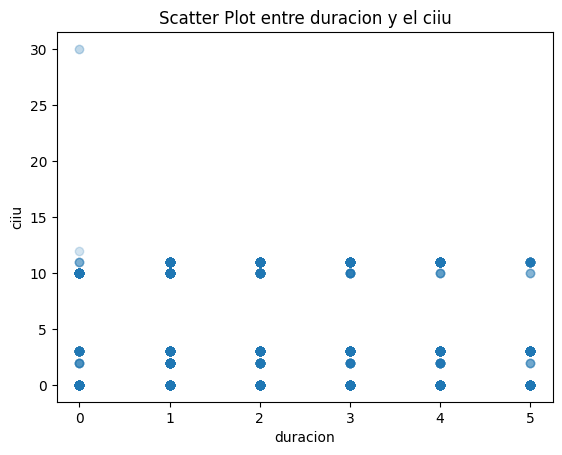

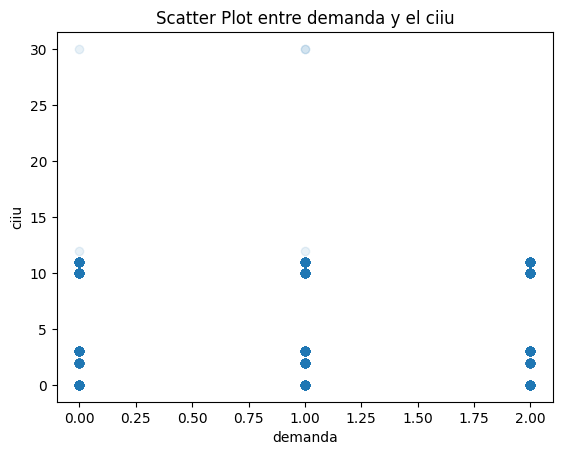

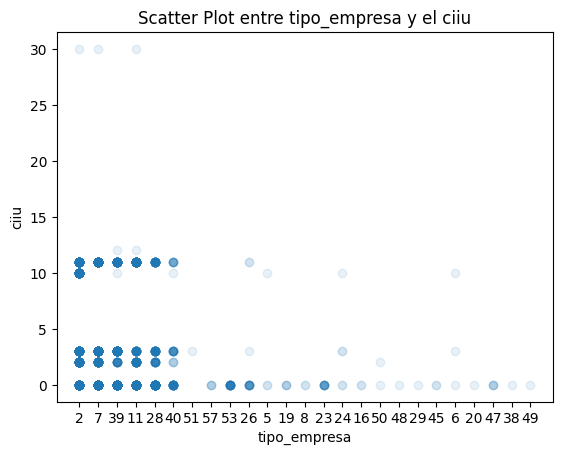

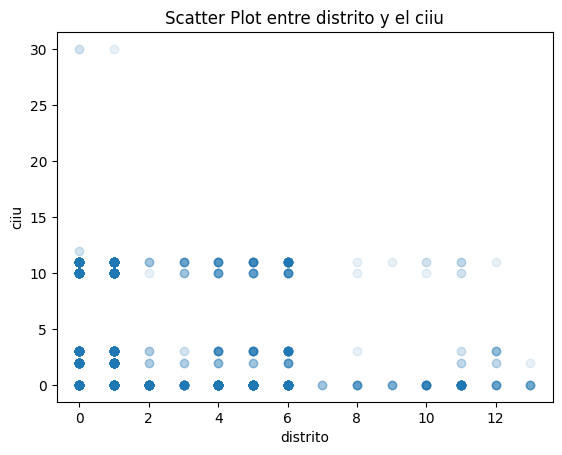

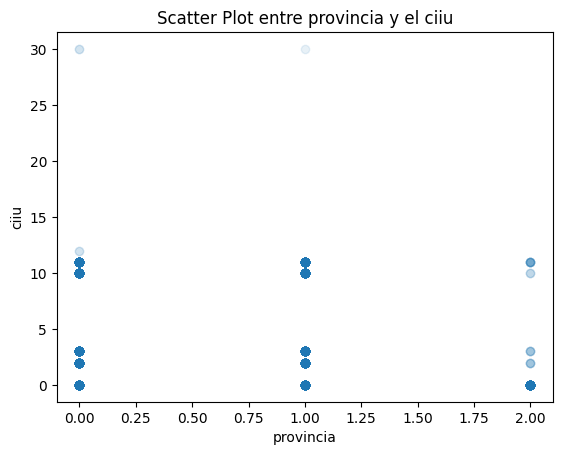

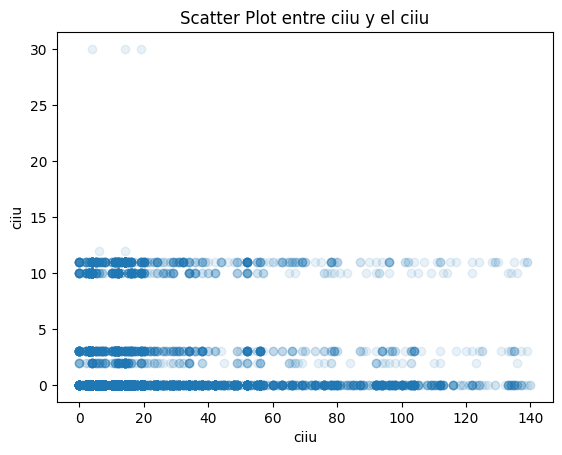

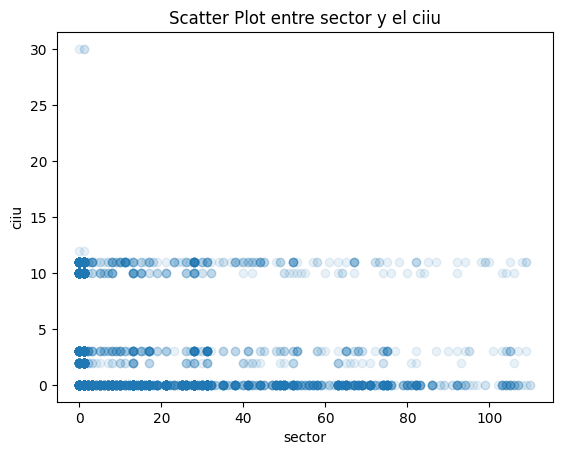

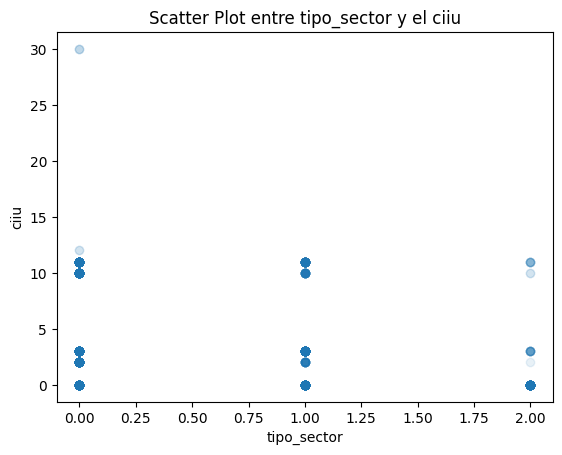

In [ ]:
for variable in xtrain:
    # Crear un gráfico de dispersión para cada característica en xtrain, indicar una relación fuerte entre la variable dependiente e independiente.
    plt.scatter(xtrain[variable], ytrain, alpha=0.10)
    plt.title(f'Scatter Plot entre {variable} y la demanda')
    plt.xlabel(variable)
    plt.ylabel('Demanda')
    plt.show()

In [ ]:
# Crea el modelo de regresión lineal para el conjunto de entrenamiento
modelo_train=sklm.LinearRegression()

# Entrena el modelo de regresión lineal con los datos de entrenamiento
modelo_train.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
# Crea el modelo de regresión lineal para el conjunto de prueba
modelo_test=sklm.LinearRegression()

# Entrena el modelo de regresión lineal con los datos de prueba
modelo_test.fit(xtest,ytest)

LinearRegression()

In [ ]:
# Imprime el R2 del modelo en el conjunto de entrenamiento
print("R2 en set de entrenamiento = ", modelo_train.score(xtrain, ytrain))

# Imprime el R2 del modelo en el conjunto de prueba
print("R2 en set de prueba = ", modelo_test.score(xtest, ytest))

R2 en set de entrenamiento =  0.4650724182811461
R2 en set de prueba =  0.4609536087384194


In [ ]:
modelo_train.coef_

array([[-1.05864500e-02,  7.95338244e-03,  7.99015821e-03,
        -5.68846806e-02, -3.87536647e-03,  3.77713636e-02,
         1.01572093e-04, -4.24795914e-06, -5.12991565e-02,
         6.24633269e-02,  2.77768494e-01]])

In [ ]:
modelo_test.coef_

array([[ 6.23049534e-03,  7.59180090e-03,  1.11453357e-02,
        -3.48237232e-02,  2.87315932e-03,  3.62312528e-02,
         1.16475990e-04, -7.81389716e-06, -4.85121235e-02,
         9.03274922e-02,  2.30372815e-01]])

In [ ]:
pesos=pd.DataFrame({"Caracteristica":xtrain.columns,"abs(pesos)":abs(modelo_train.coef_[0])}) #obtencion de los valores absolutos de los coeficientes
pesos.sort_values("abs(pesos)", ascending=False) #ascending=False  = que no considere en ascendente

,Caracteristica,abs(pesos)
10,mercado_obj,0.277768
9,tipo_sector,0.062463
3,provincia,0.056885
8,sector,0.051299
5,ciiu,0.037771
0,duracion,0.010586
2,distrito,0.007990
1,tipo_empresa,0.007953
4,estado,0.003875
6,Costo_min,0.000102


<Axes: xlabel='Caracteristica'>

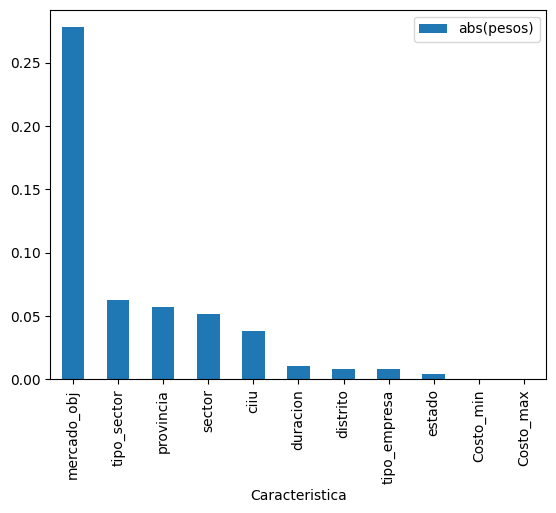

In [ ]:
pesos.sort_values("abs(pesos)",ascending=False).plot(
    x="Caracteristica", y="abs(pesos)", kind="bar"
)

In [ ]:
xtrain.min()

duracion         0.0
tipo_empresa      11
distrito           0
provincia          0
estado           0.0
ciiu               0
Costo_min       1500
Costo_max       6000
sector             0
tipo_sector        0
mercado_obj        0
dtype: object

In [ ]:
xtrain.max()

duracion          5.0
tipo_empresa        8
distrito           13
provincia           2
estado           30.0
ciiu              140
Costo_min       20000
Costo_max       50000
sector            110
tipo_sector         2
mercado_obj         1
dtype: object

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
scaler.fit(xtrain)
xtrain_escalado = scaler.transform(xtrain)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(xtest)
xtest_escalado=scaler.transform(xtest)

In [ ]:
print(xtrain_escalado.min(axis=0)) #Imprimiendo los escalados, min y max de la data de prueba
print(xtrain_escalado.max(axis=0))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
print(xtest_escalado.min(axis=0)) #Imprimiendo los escalados, min y max de la data de entrenamiento
print(xtest_escalado.max(axis=0))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
print(xtest_escalado.min(axis=1))
print(xtest_escalado.max(axis=1))

[0. 0. 0. ... 0. 0. 0.]
[1.  1.  1.  ... 1.  0.8 1. ]


In [ ]:
modelo=sklm.LinearRegression()
modelo.fit(xtrain_escalado, ytrain.to_numpy().flatten())

LinearRegression()

In [ ]:
print("R2 en set de entrenamiento = ", modelo.score(xtrain_escalado, ytrain))
print("R2 en set de prueba= ", modelo.score(xtest_escalado, ytest))

R2 en set de entrenamiento =  0.4650724182811462
R2 en set de prueba=  0.4567338336274873


In [ ]:
pesos=pd.DataFrame({"Caracteristicas":xtrain.columns,
                    "pesos":modelo.coef_,
                    "abs(pesos)":abs(modelo.coef_)})
pesos.sort_values("abs(pesos)",ascending=False)

,Caracteristicas,pesos,abs(pesos)
8,sector,-5.642907,5.642907
5,ciiu,5.287991,5.287991
6,Costo_min,1.879084,1.879084
1,tipo_empresa,0.437436,0.437436
10,mercado_obj,0.277768,0.277768
7,Costo_max,-0.186910,0.186910
9,tipo_sector,0.124927,0.124927
4,estado,-0.116261,0.116261
3,provincia,-0.113769,0.113769
2,distrito,0.103872,0.103872


<Axes: xlabel='Caracteristicas'>

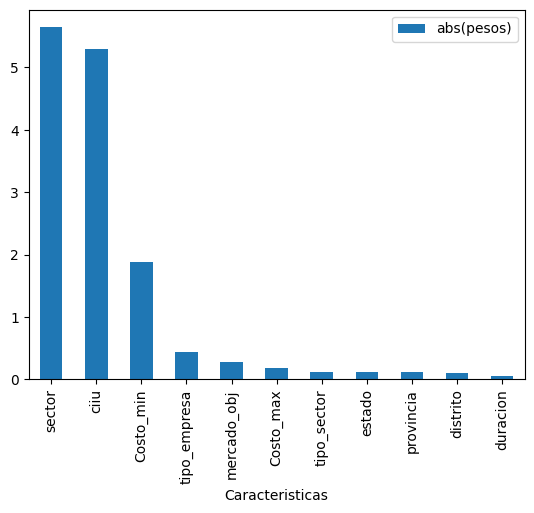

In [ ]:
pesos.sort_values("abs(pesos)",ascending=False).plot(
    x="Caracteristicas",y="abs(pesos)",kind="bar"
)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
scaler.fit(xtrain)

StandardScaler()

In [ ]:
scaler=StandardScaler()
scaler.fit(xtest)

StandardScaler()

In [ ]:
xtrain_escalado=scaler.transform(xtrain)
xtest_escalado=scaler.transform(xtest)

In [ ]:
modelo=sklm.LinearRegression()
modelo.fit(xtrain_escalado,ytrain)

LinearRegression()

In [ ]:
modelo=sklm.LinearRegression()
modelo.fit(xtest_escalado,ytest)

LinearRegression()

In [ ]:
print("R2 en set entrenamiento= {:.2f}".format(modelo.score(xtrain_escalado,ytrain)))
print("R2 en set prueba= = {:.2f}".format(modelo.score(xtest_escalado,ytest)))

R2 en set entrenamiento= 0.46
R2 en set prueba= = 0.46


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly=PolynomialFeatures(degree=3)
xtrain_poly=poly.fit_transform(xtrain) #transformamos la data xtrain
xtest_poly=poly.transform(xtest)

In [ ]:
modelo_poly=sklm.LinearRegression()
modelo_poly.fit(xtrain_poly,ytrain)
print("R2 xtrain: {:.3f}".format(modelo_poly.score(xtrain_poly,ytrain)))
print("R2 xtest: {:.3f}".format(modelo_poly.score(xtest_poly,ytest)))

R2 xtrain: 0.872
R2 xtest: 0.851


In [ ]:
scaler=StandardScaler()
scaler.fit(xtrain_poly)
xtrain_poly_escalado = scaler.transform(xtrain_poly)
xtest_poly_escalado = scaler.transform(xtest_poly)
modelo_poly_esc=sklm.LinearRegression()
modelo_poly_esc.fit(xtrain_poly_escalado,ytrain)
print("R2 xtrain: {:.3f}".format(modelo_poly_esc.score(xtrain_poly_escalado,ytrain)))
print("R2 xtest: {:.3f}".format(modelo_poly_esc.score(xtest_poly_escalado,ytest)))

R2 xtrain: 0.873
R2 xtest: 0.841


In [ ]:
ypred= modelo_train.predict(xtest)
ypred2= modelo_poly_esc.predict(xtest_poly_escalado)

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_pred = r2_score(ytest,ypred)
r2_pred_escalado = r2_score(ytest,ypred2)

Text(0.5, 1.0, 'Grafica Regresion con Poly Escalado')

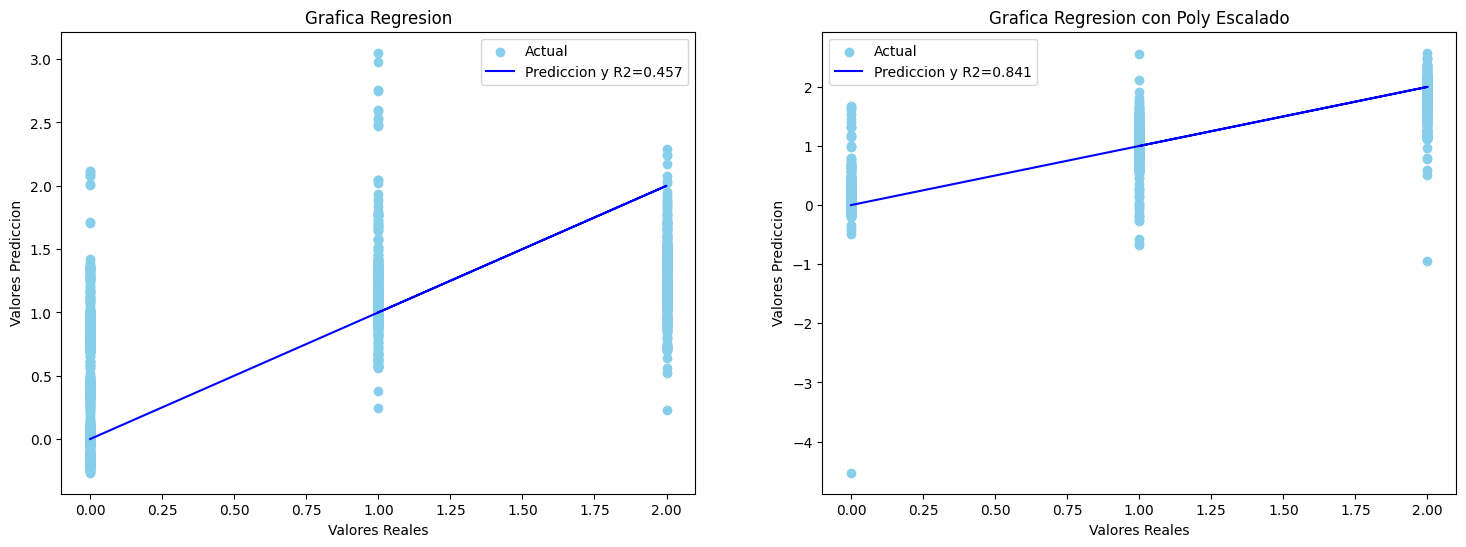

In [ ]:
plt.figure (figsize= (18,6))
plt.subplot(1,2,1)
plt.scatter(ytest, ypred, c='skyblue', label='Actual', )
plt.plot(ytest, ytest, c='blue', label='Prediccion y R2={:.3f}'.format(r2_pred))
plt.xlabel("Valores Reales")
plt.ylabel("Valores Prediccion")
plt.legend()
plt.title("Grafica Regresion")


plt.subplot(1,2,2)
plt.scatter(ytest, ypred2, c='skyblue', label='Actual', )
plt.plot(ytest, ytest, c='blue', label='Prediccion y R2={:.3f}'.format(r2_pred_escalado))
plt.xlabel("Valores Reales")
plt.ylabel("Valores Prediccion")
plt.legend()
plt.title("Grafica Regresion con Poly Escalado")

* from sklearn.metrics import mean_squared_error, r2_score, f1_score: Importa
* funciones para calcular métricas de evaluación de modelos.
* def poly_reg(x, y, x_test, degree):: Define una función para crear un modelo de regresión polinomial.
* model = LinearRegression(): Crea un modelo de regresión lineal.
* model.fit(x, y): Entrena el modelo utilizando los datos de entrenamiento x e y.
* yhat = model.predict(x_test): Realiza predicciones sobre los datos de prueba x_test.
* return yhat: Devuelve las predicciones realizadas.
* def score(y, yhat): Define una función para calcular métricas de evaluación del modelo.
* r2 = r2_score(y, yhat): Calcula el coeficiente de determinación R2.
* rmse = np.sqrt(mean_squared_error(y, yhat)): Calcula la raíz del error cuadrático medio (RMSE).
* return (r2, rmse): Devuelve un tuple con los valores de R2 y RMSE.
* yhat = poly_reg(x, y, x, 4): Llama a la función poly_reg para crear un modelo de regresión polinomial de grado 4 y realizar predicciones sobre los mismos datos de entrenamiento x.


<h3>OTROS METODOS

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso

# Ajustar el modelo Lasso
modelo_lasso = Lasso(alpha=0.0001)  # Ajuste el parámetro alpha
modelo_lasso.fit(xtrain_poly_escalado, ytrain)

# Realizar predicciones con el modelo Lasso
y_pred_train = modelo_lasso.predict(xtrain_poly_escalado)
y_pred_test = modelo_lasso.predict(xtest_poly_escalado)

# Evaluar el rendimiento del modelo
print("R2 xtrain (Lasso): {:.2f}".format(modelo_lasso.score(xtrain_poly_escalado, ytrain)))
print("R2 xtest (Lasso): {:.2f}".format(modelo_lasso.score(xtest_poly_escalado, ytest)))


R2 xtrain (Lasso): 0.74
R2 xtest (Lasso): 0.71


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.625e+02, tolerance: 4.840e-01
  model = cd_fast.enet_coordinate_descent(


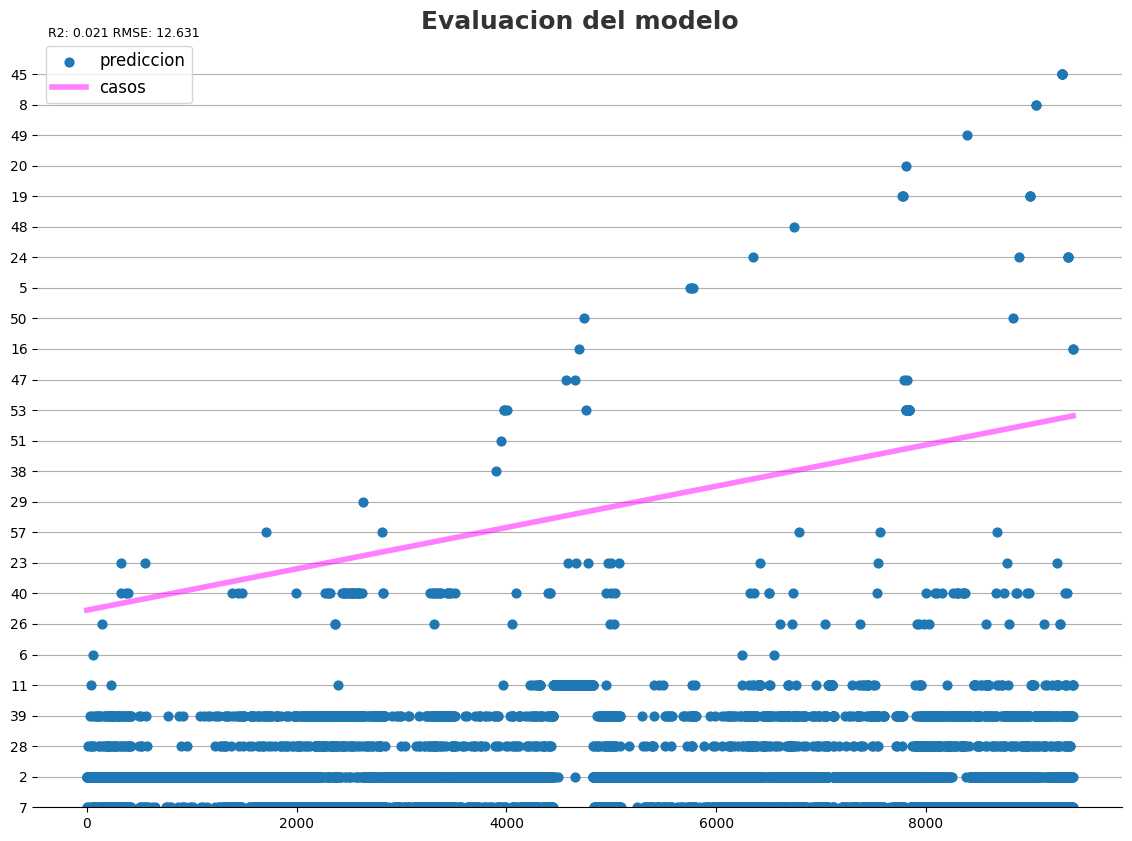

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, f1_score
start = 0
end = len(data)
x = np.asarray(range(start, end)).reshape(-1, 1)
y = data.iloc[start:, 1]
def poly_reg(x, y, x_test, degree):


    # Crea el modelo
    model = LinearRegression()

    # Entrena el modelo
    model.fit(x, y)

    # Realiza predicciones
    yhat = model.predict(x_test)

    return yhat
def score(y, yhat):
    r2 = r2_score(y,yhat)
    rmse = np.sqrt(mean_squared_error(y,yhat))
    return (r2,rmse)

yhat = poly_reg(x, y, x, 4)

fig, ax = plt.subplots(figsize=(14, 10))
plt.scatter(x, y, s=40)
plt.plot(x, yhat, color='magenta', linestyle='solid', linewidth=4, alpha=0.5)
plt.title('Evaluacion del modelo', fontsize=18, fontweight='bold', color='#333333')
plt.legend(labels=['prediccion', 'casos'], fontsize=12)
plt.text(0.01, 1.0, s='R2: %.3f RMSE: %.3f' % score(y, yhat), transform=ax.transAxes, fontsize=9)
plt.grid(which='major', axis='y')
ax.set_axisbelow(True)
ax.set_ylim(0)
[ax.spines[side].set_visible(False) for side in ['left', 'right', 'top']]
plt.show()